# Multitask Shapes – interactive play  
  
This notebook lets you **play the customised “Multitask Shapes” environment** that you pasted.  
At each step you’ll be asked for an action:

| index | meaning  |
|-------|----------|
| 0     | **UP**   |
| 1     | **DOWN** |
| 2     | **LEFT** |
| 3     | **RIGHT**|
| 4     | **PICK** |
| 5     | **DROP** |

The notebook will  
* execute the action,  
* print the new reward & raw observation, and  
* display the rendered frame.

> **Prerequisites**  
> * `shapes.py`, `multitask_shapes.py`, `utils.py`, the `assets/` folder and your YAML hyper‑parameter file must be provided.
> * Python ≥ 3.9 with the packages in the first code‑cell installed.


In [1]:
# ------------------------------------------------------------
# (Optional) install runtime dependencies
# ------------------------------------------------------------
# If you are missing any of these packages, remove the leading
# '#' and run the cell once.
#
# !pip install -q gymnasium numpy opencv-python-headless matplotlib pyyaml


In [2]:
# ------------------------------------------------------------
# Imports & utility helpers
# ------------------------------------------------------------
import os, yaml, numpy as np, cv2, matplotlib.pyplot as plt
from typing import Dict
from IPython.display import clear_output
import time

# Adjust the import below if your python file has a different name
from envs.shapes.multitask_shapes import ShapesAttrCombFactory
from envs.shapes.shapes import RND_FTR_RNG
from utils import setup_artefact_paths

# Helper to display a rendered frame inline
def show_frame(img):
    plt.figure(figsize=(4,4))
    # convert BGR (OpenCV) ➜ RGB (matplotlib)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

def _decode_onehot_slice(segment: np.ndarray):
    if segment.size == 0 or np.count_nonzero(segment) == 0:
        return None
    return int(np.argmax(segment))

def _random_feature_values(cnfd_ftrs: Dict, n_cnfd: int):
    return [int(cnfd_ftrs[f"random_feature_{i}"]) for i in range(n_cnfd)]

def semantically_interpretable_state(obs: np.ndarray, env, features: Dict, featureset_id: int):
    # Multitask wrapper keeps the underlying Shapes env in _env
    active_env = env._env if hasattr(env, "_env") else env
    game_map = active_env.map

    print(f"Agent is at {game_map.agent_loc[0]}, {game_map.agent_loc[1]}.")

    for obj in game_map._objects:
        semantic_str = f"{obj.colour} {obj.shape} at {obj.loc[0]}, {obj.loc[1]}."
        if game_map.n_cnfd_ftrs > 0:
            semantic_str += f" random={_random_feature_values(obj.cnfd_ftrs, game_map.n_cnfd_ftrs)}."
        if obj.picked_up:
            semantic_str += " Object in inventory."
        print(semantic_str)

    for door in game_map._doors:
        semantic_str = f"{door.colour} door at {door.loc[0]}, {door.loc[1]} is "
        semantic_str += "locked." if door.locked else "unlocked."
        if game_map.n_cnfd_ftrs > 0:
            semantic_str += f" random={_random_feature_values(door.cnfd_ftrs, game_map.n_cnfd_ftrs)}."
        print(semantic_str)

    if featureset_id != 1:
        return

    # Use Shapes semantic-feature builder to locate semantic tail precisely.
    base_obs_size = active_env.sf._one_hot_encode().size
    semantic_obs = obs[base_obs_size:]
    if semantic_obs.size == 0:
        return

    cursor = 0
    bias = int(semantic_obs[cursor])
    cursor += 1
    print(f"Semantic bias: {bias}")

    if game_map.terminal_map_loc is not None and cursor < semantic_obs.size:
        at_terminal = int(semantic_obs[cursor])
        cursor += 1
        print(f"Semantic at terminal: {at_terminal}")

    colour_rng = game_map.ftr_category_to_range["colour"]
    shape_rng = game_map.ftr_category_to_range["shape"]

    colour_idx = _decode_onehot_slice(semantic_obs[cursor:cursor + colour_rng])
    cursor += colour_rng
    shape_idx = _decode_onehot_slice(semantic_obs[cursor:cursor + shape_rng])
    cursor += shape_rng

    semantic_colour_str = features["colour"][colour_idx] if colour_idx is not None else "none"
    semantic_shape_str = features["shape"][shape_idx] if shape_idx is not None else "none"

    print(f"Semantic colour: {semantic_colour_str}")
    print(f"Semantic shape: {semantic_shape_str}")

    if game_map.n_cnfd_ftrs > 0:
        semantic_random_vals = []
        for _ in range(game_map.n_cnfd_ftrs):
            rnd_idx = _decode_onehot_slice(semantic_obs[cursor:cursor + RND_FTR_RNG])
            cursor += RND_FTR_RNG
            semantic_random_vals.append(rnd_idx)
        print(f"Semantic random features: {semantic_random_vals}")



/home/djordje/miniconda3/envs/rlexp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ------------------------------------------------------------
# Load hyper‑parameters & create the environment
# ------------------------------------------------------------
parent_dir = os.path.dirname(os.getcwd())
# Fill yaml_path as desired, the rest should work as is.
yaml_path = os.path.join(parent_dir, "envs", "shapes", "configs", "shapes.yaml")
# yaml_path = os.path.join(parent_dir, "envs", "shapes", "configs", "shapes_lin.yaml")

script_path = os.path.join(os.getcwd(), 'multitask_shapes_play.ipynb')
store_path, _ = setup_artefact_paths(script_path)

with open(yaml_path, 'r') as f:
    hparams = yaml.safe_load(f)

hparams = hparams["environment"] if "environment" in hparams else hparams
FEATURESET_ID = hparams.get("featureset_id", 0)

env = ShapesAttrCombFactory(
    hparams=hparams,
    store_path=store_path
).get_env(set_id="TRAIN")
print('Environment ready ✔')



Environment ready ✔


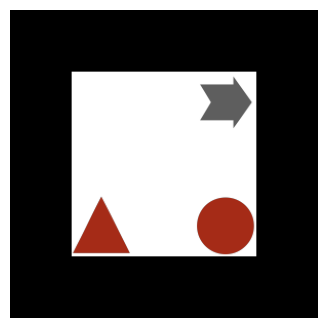

Episode finished.
Instruction: Pick up yellow square
Current observation: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 1 0 0 0 0 1 0 0 0 0 0 0 1 3 3 1 0 0 0 1
 0 0 0 0 0 0 0 1 1 3 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
Agent is at 1, 3.
red triangle at 3, 1. random=[1].
red ball at 3, 3. random=[1].
Semantic bias: 1
Semantic at terminal: 1
Semantic colour: none
Semantic shape: none
Semantic random features: [None]
Total steps: 4   Return: 13


In [7]:
# ---- initial reset ----
obs, _ = env.reset()
step = 0
total_reward = 0
last_reward = None          # stores reward from previous step
terminated = truncated = False

while not (terminated or truncated):
    clear_output(wait=True)

    # -------- show current frame ----------
    frame = env.render_frame()
    show_frame(frame)

    # -------- show textual info -----------
    print(f"Step: {step}")
    print(f"Return so far: {total_reward}")
    if last_reward is not None:
        print(f"Reward from previous action: {last_reward}")
    print(f"Instruction: {obs['instr']}")
    print(f"Current observation: {obs['features']}")
    semantically_interpretable_state(
        obs=obs["features"],
        env=env,
        features=hparams["features"],
        featureset_id=FEATURESET_ID,
    )
    
    print("Choose action – 0:UP  1:DOWN  2:LEFT  3:RIGHT  4:PICK UP  5:DROP 6:USE")

    # -------- get action ------------------
    action = int(input("Your action index: ").strip())
    if action not in range(7):
        print("❌  Please enter an integer 0‑6.")
        break

    # -------- environment step ------------
    next_obs, reward, terminated, truncated, _ = env.step(action)

    # update bookkeeping
    last_reward = reward
    total_reward += reward
    obs = next_obs
    step += 1

# final display
clear_output(wait=True)
frame = env.render_frame()
show_frame(frame)
print("Episode finished.")
print(f"Instruction: {obs['instr']}")
print(f"Current observation: {obs['features']}")
semantically_interpretable_state(
    obs=obs["features"],
    env=env,
    features=hparams["features"],
    featureset_id=FEATURESET_ID,
)
print(f"Total steps: {step}   Return: {total_reward}")
obs, _ = env.reset()

